# Lab 1

## Problem 1

### Table of aesthetics and mapped variables for each plot:

| Plot | Aesthetic | Variable | 
| ---- | --------- | -------- |
| **Plot 1** | x-position | Income |
|            | y-position | Life Expectancy |
|            | color      | World Regions | 
|            | point size | Population |
| **Plot 2** | x-position | Exports (% of GDP) |
|            | y-position | Imports (% of GDP) |
|            | color      | World Regions | 
|            | point size | Energy Use |
| **Plot 3** | x-position | Individuals Using the Internet |
|            | y-position | GDP per Capita |
|            | color      | World Regions | 
|            | point size | Income |

## Problem 2


In [ ]:
from plotnine import *
import pandas as pd

q1 = pd.read_csv("data\q1data.csv")
q2 = pd.read_csv("data\q2data.csv")
q3 = pd.read_csv("data\q3data.csv")

### Plot 1

In [ ]:
# Fix NA values by using gapminder data

q1.loc[q1["country"] == "Eswatini", "four_regions"] = "africa"
q1.loc[q1["country"] == "North Macedonia", "four_regions"] = "europe"


q1.head()

,income,life_exp,population,year,country,four_regions,six_regions,eight_regions,world_bank_region
0,1910.0,61.0,29200000.0,2010,Afghanistan,asia,south_asia,asia_west,South Asia
1,11100.0,78.1,2950000.0,2010,Albania,europe,europe_central_asia,europe_east,Europe & Central Asia
2,11100.0,74.7,36000000.0,2010,Algeria,africa,middle_east_north_africa,africa_north,Middle East & North Africa
3,46900.0,81.9,84500.0,2010,Andorra,europe,europe_central_asia,europe_west,Europe & Central Asia
4,7680.0,60.8,23400000.0,2010,Angola,africa,sub_saharan_africa,africa_sub_saharan,Sub-Saharan Africa


C:\Users\jaxle\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


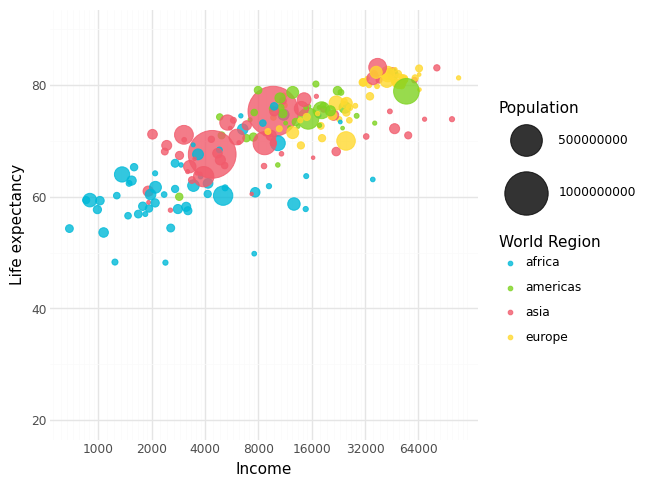

In [81]:
# Create plot dropping countries where income or life_exp == NA

(
    ggplot(q1.dropna(subset=["income", "life_exp"]),
           aes(x="income",
               y="life_exp",
               color="four_regions",
               size="population"))
    + geom_point(alpha=0.8, stroke=0.4)
    + scale_size_continuous(range=(1, 20))
    + scale_colour_manual(values={"africa": "#00B9D8", "americas": "#7ED321", "asia": "#F15B6C", "europe": "#FFD92F"})
    + scale_x_log10(
        breaks=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]
    )
    + scale_y_continuous(limits=(20, 90))
    + labs(
        x="Income",
        y="Life expectancy",
        color="World Region",
        size="Population"
    )
    + theme_minimal()
)

### Plot 2

In [72]:
# Drop countries whose imports, exports, or energy values == NA

q2_clean = q2.dropna(subset=["imports","exports","energy"])

# Convert energy column to numeric

q2["energy"] = q2["energy"].apply(
    lambda x: float(x[:-1]) * 1000 if isinstance(x, str) and x.endswith("k") else float(x)
)


# For countries with valid imports, exports, and energy data, fix four_regions designations

q2_clean.loc[q2_clean["country"] == "North Macedonia", "four_regions"] = "europe"

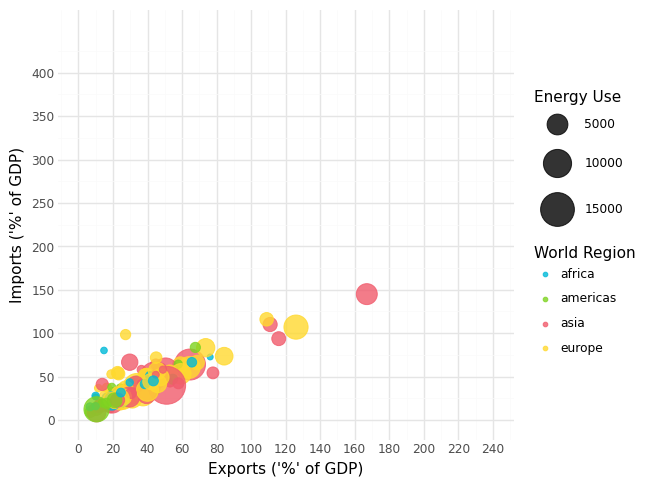

In [88]:
(
    ggplot(q2_clean,
           aes(x="exports",
               y="imports",
               color="four_regions",
               size="energy"))
    + geom_point(alpha=0.8, stroke=0.4)
    + scale_size_continuous(range=(1, 15))
    + scale_colour_manual(values={"africa": "#00B9D8", "americas": "#7ED321", "asia": "#F15B6C", "europe": "#FFD92F"})
    + scale_x_continuous(limits=(0,240),
        breaks=[0,20,40,60,80,100,120,140,160,180,200,220,240]
    )
    + scale_y_continuous(limits=(0, 450),
    breaks=[0,50,100,150,200,250,300,350,400])
    + labs(
        x="Exports ('%' of GDP)",
        y="Imports ('%' of GDP)",
        color="World Region",
        size="Energy Use"
    )
    + theme_minimal()
)

### Plot 3

In [78]:
# Drop countries whose gdp, income, or internet_users values == NA

q3_clean = q3.dropna(subset=["internet_users","gdp","income"])

# Fill in four_regions values based on gapminder data for countries with no NA values in relevant categories

q3_clean.loc[q3_clean["country"] == "Eswatini", "four_regions"] = "africa"
q3_clean.loc[q3_clean["country"] == "North Macedonia", "four_regions"] = "europe"

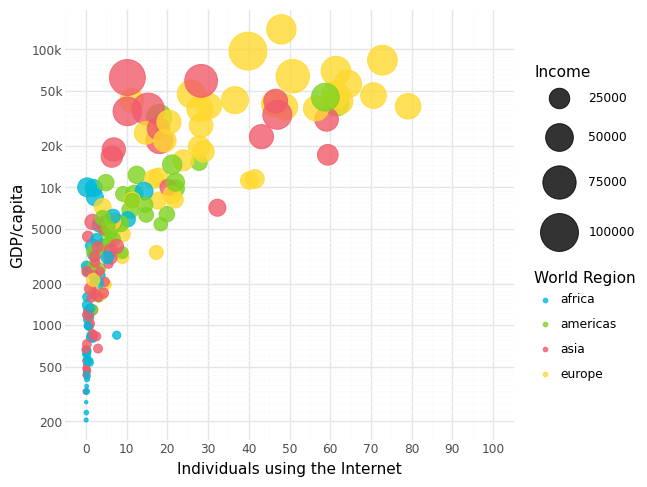

In [80]:
(
    ggplot(q3_clean,
           aes(x="internet_users",
               y="gdp",
               color="four_regions",
               size="income"))
    + geom_point(alpha=0.8, stroke=0.4)
    + scale_size_continuous(range=(1, 15))
    + scale_colour_manual(values={"africa": "#00B9D8", "americas": "#7ED321", "asia": "#F15B6C", "europe": "#FFD92F"})
    + scale_x_continuous(limits=(0,100),
        breaks=[0,10,20,30,40,50,60,70,80,90,100]
    )
    + scale_y_log10(breaks=[200,500,1000,2000,5000,10000,20000,50000,100000],
    labels=["200","500","1000","2000","5000","10k","20k","50k","100k"]
    )
    + labs(
        x="Individuals using the Internet",
        y="GDP/capita",
        color="World Region",
        size="Income"
    )
    + theme_minimal()
)

## Problem 3

**You could use a geometry such as `geom_text` to visualize the data. It is, very similar to `geom_point`, in that it plots the values and adjusts the size according to the specified scale. However, the main drawback is that in areas where there are many points clustered together, it gets very difficult to both read the text, and overall makes the plot more difficult to read**

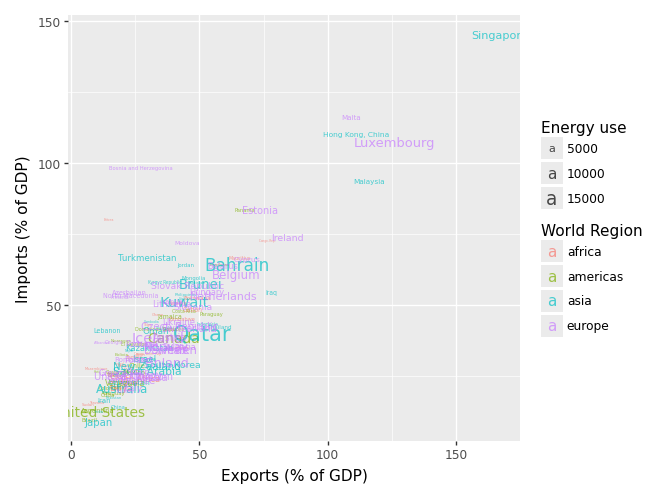

In [94]:
(
    ggplot(q2_clean,
           aes(x="exports",
               y="imports",
               color="four_regions",
               size="energy",
               label="country"))
    + geom_text(alpha=0.7)
    + scale_size_continuous(range=(1,15))
    + labs(
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
        color="World Region",
        size="Energy use"
    )
)